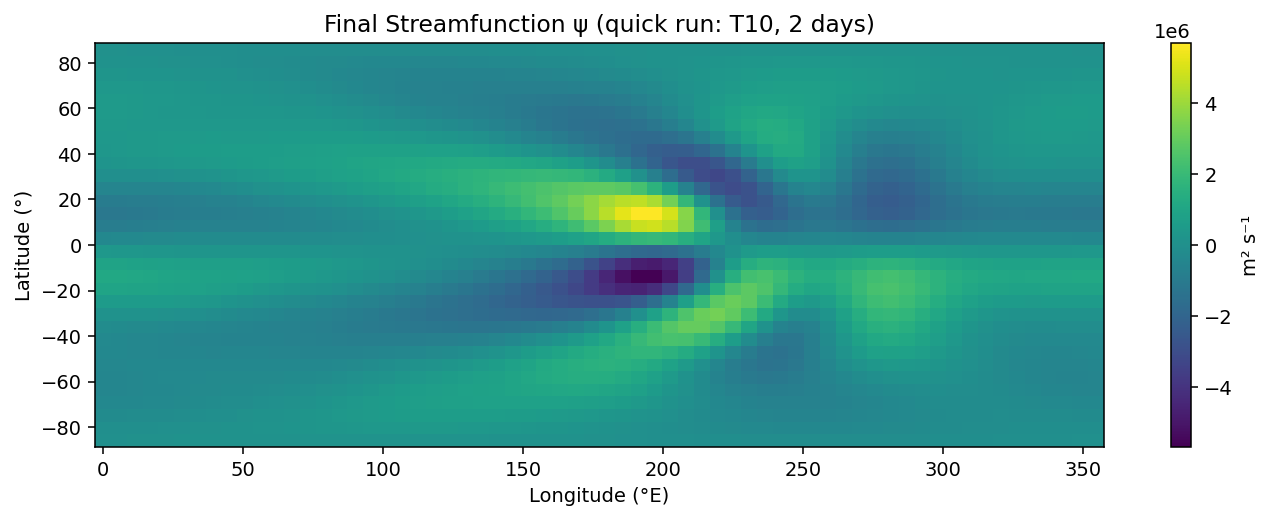

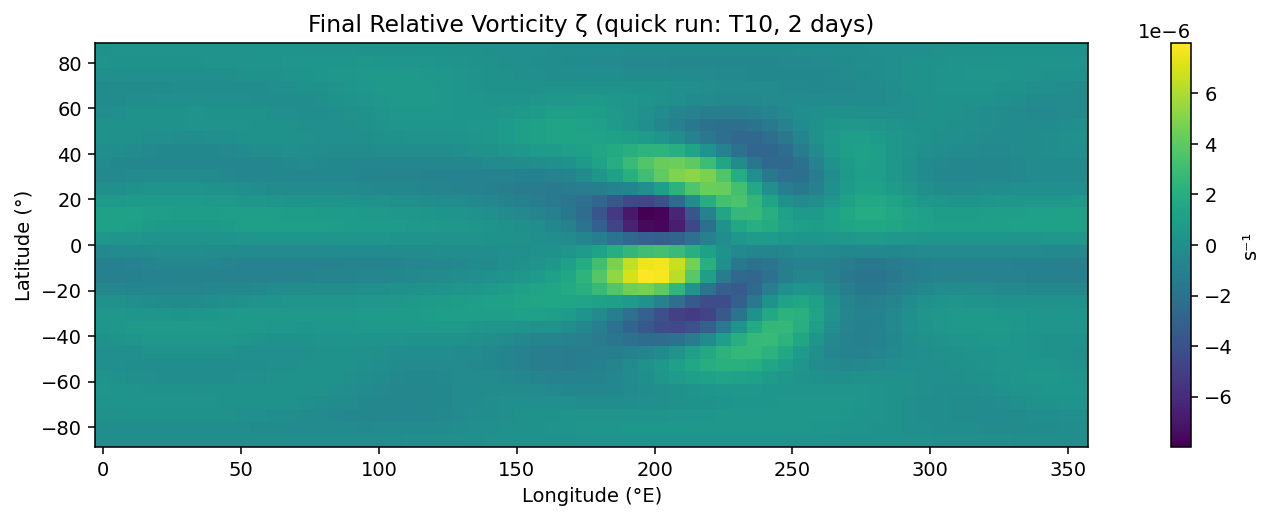

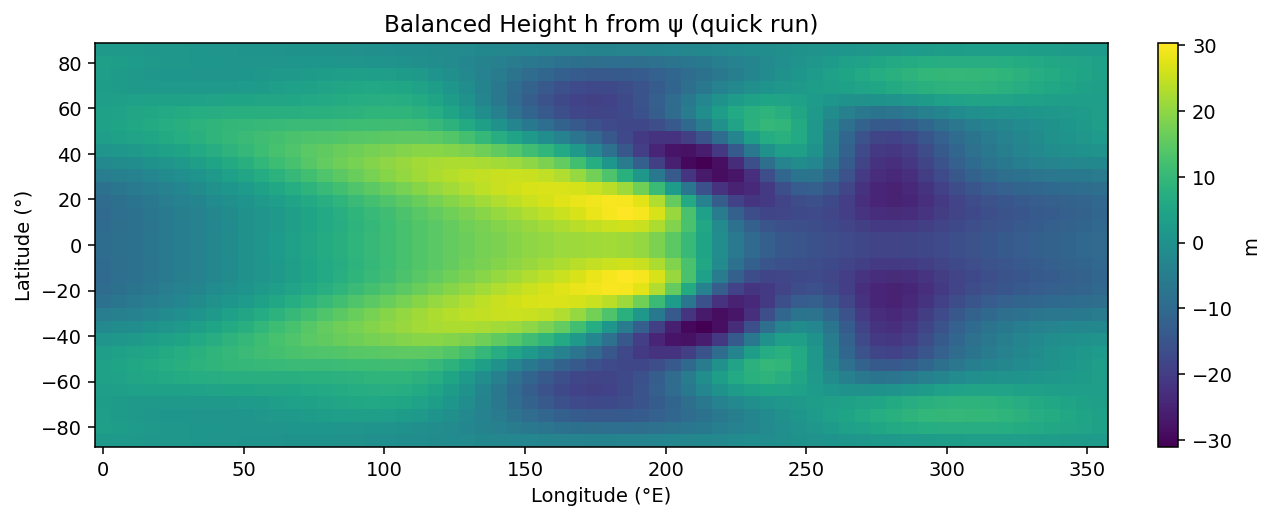

In [4]:
# Switch to a lighter "quick-run" configuration to generate plots without timing out
import numpy as np
import matplotlib.pyplot as plt

# Override globals for a faster demo
pi = np.pi
re = 6.371e6
omega = 7.292e-5
g = 9.8

lmax = 10   # down from 21
nx   = 64   # down from 128
ny   = 32   # down from 64
nk   = lmax*(lmax+2)+1
nk2  = lmax*lmax + 4*lmax + 4

dt = 60.0*60.0
nt = 24*5   # 2 days for speed
rdrag = -1.0/(60.0*60.0*24.0*7.0)
fwdskip = 10
outskip = 12  # save sparsely to reduce overhead
nu = 2.5e5
diff_l_m_threshold = 8  # adapt to new lmax

# Rebuild all dependent functions quickly (reuse previous definitions but ensure they see new globals)
def idx(l, m):
    return (1 + (l+1)*l - m) - 1

def leggauss_lat(ny):
    x, w = np.polynomial.legendre.leggauss(ny)
    lats = np.arcsin(x) * 180.0/pi
    return lats, w, x

def plgndr_norm_all(lmax_local, mabs, x):
    L = lmax_local + 1
    out = np.zeros((L+1, x.size), dtype=float)
    m = mabs
    if m == 0:
        pmm = np.sqrt((2*m+1)/(4*pi)) * np.ones_like(x)
    else:
        omx2 = (1.0 - x)*(1.0 + x)
        fact = 1.0
        pmm = np.ones_like(x)
        for _ in range(1, m+1):
            pmm *= omx2 * fact/(fact+1.0)
            fact += 2.0
        pmm = np.sqrt((2*m+1)*pmm/(4.0*pi))
        pmm = np.where((m % 2)==1, -pmm, pmm)
    out[m, :] = pmm
    if L == m:
        return out
    if m+1 <= L:
        out[m+1, :] = x * np.sqrt(2.0*m + 3.0) * pmm
    oldfact = np.sqrt(2.0*m + 3.0)
    for ll in range(m+2, L+1):
        fact = np.sqrt((4.0*ll*ll - 1.0) / (ll*ll - m*m))
        out[ll, :] = (x * out[ll-1, :] - out[ll-2, :]/oldfact) * fact
        oldfact = fact
    return out

def precompute_alp(lmax_local, lats_deg, x):
    ny_local = lats_deg.size
    L = lmax_local + 1
    rows = (L+2)*(L) + 4  # safe upper bound; we will index up to nk2-1
    alp = np.zeros((nk2, ny_local), dtype=float)
    for mabs in range(0, L+1):
        Plm = plgndr_norm_all(lmax_local, mabs, x)
        for l in range(mabs, L+1):
            if mabs == 0:
                m_list = (0,)
            else:
                m_list = (-mabs, mabs)
            for m in m_list:
                ik = idx(l, m)
                alp[ik, :] = Plm[l, :]
    return alp

def spec2grid(fields, alp, lons, wlat):
    nx_local = lons.size
    ny_local = alp.shape[1]
    out = np.zeros((nx_local, ny_local), dtype=float)
    mvals = np.arange(-(lmax+1), (lmax+1)+1)
    E = np.exp(1j*np.outer(lons, mvals))  # (nx, nm)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            Y_lon = E[:, m + (lmax+1)]          # (nx,)
            Y_lat = alp[ik, :]                  # (ny,)
            out += np.real(Y_lon[:, None] * Y_lat[None, :] * fields[ik])
    return out

def grid2spec(fieldg, alp, lons, wlat):
    nx_local, ny_local = fieldg.shape
    fields = np.zeros(nk2, dtype=complex)
    dlam = 2*pi/nx_local
    mmax = lmax+1
    mvals = np.arange(-mmax, mmax+1)
    E_conj = np.exp(-1j*np.outer(np.linspace(0, 2*pi-dlam, nx_local), mvals))  # (nx, nm)
    Fm = (fieldg.T @ E_conj) * dlam     # (ny, nm)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            mcol = m + mmax
            fields[ik] = np.sum( Fm[:, mcol] * alp[ik, :] * wlat )
    return fields

def vort2psi(vorts):
    psis = np.zeros_like(vorts, dtype=complex)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            psis[ik] = (-re*re/(l*(l+1)) if l>0 else 0.0) * vorts[ik]
    return psis

def invlap(fields):
    invs = np.zeros_like(fields, dtype=complex)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            invs[ik] = (-re*re/(l*(l+1)) if l>0 else 0.0) * fields[ik]
    return invs

def ddx_spec_to_grid(vars_spec, alp, lons, lats_rad):
    dspec = np.zeros_like(vars_spec, dtype=complex)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            dspec[ik] = 1j * m * vars_spec[ik]
    ddx = spec2grid(dspec, alp, lons, None)
    coslat = np.cos(lats_rad)[None, :]
    return ddx / (re * coslat)

def ddy_spec_to_grid(vars_spec, alp, lons, lats_rad, wlat, x):
    ddys = np.zeros_like(vars_spec, dtype=complex)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            rl = float(l); rm = float(m)
            if l == 0:
                ddys[ik] = 0.0
                continue
            eta = np.sqrt( (rl*rl - rm*rm) / (4.0*rl*rl - 1.0) ) if l >= 1 else 0.0
            rlp1 = rl + 1.0
            rlm1 = rl - 1.0
            etalp1 = np.sqrt( (rlp1*rlp1 - rm*rm) / (4.0*rlp1*rlp1 - 1.0) ) if (l+1) >= 1 else 0.0
            term = 0.0+0.0j
            if l <= lmax:
                iklp1 = idx(l+1, m)
                term += (rl+2.0) * etalp1 * vars_spec[iklp1]
                if abs(m) < l:
                    iklm1 = idx(l-1, m)
                    term += -(rl-1.0) * eta * vars_spec[iklm1]
            else:
                if abs(m) < l:
                    iklm1 = idx(l-1, m)
                    term += -(rl-1.0) * eta * vars_spec[iklm1]
            ddys[ik] = term
    ddy = spec2grid(ddys, alp, lons, wlat)
    coslat = np.cos(lats_rad)[None, :]
    return ddy / (re * coslat)

def makediff(vorts):
    diffs = np.zeros_like(vorts, dtype=complex)
    for l in range(0, lmax+2):
        for m in range(-l, l+1):
            ik = idx(l, m)
            fac = (- l*(l+1)/(re*re)) if l>0 else 0.0
            diffs[ik] = nu * fac * vorts[ik] if (l - abs(m)) > diff_l_m_threshold else 0.0
    return diffs

def makeforce(lats_deg, nx_local, alp, lons, wlat):
    dl = 30.0
    dp = 25.0
    d0 = 3e-6
    lon0 = 200.0
    lat0 = 0.0
    dx = 360.0/nx_local
    lons_deg = (np.arange(nx_local) * dx + 0.5*dx)
    lon2 = (lons_deg[:, None] - lon0)**2 / (dl*dl)
    lat2 = (lats_deg[None, :] - lat0)**2 / (dp*dp)
    mask = (lon2 + lat2) <= 1.0
    f = 2.0*omega*np.sin(np.deg2rad(lats_deg))[None, :]
    forcing = -f * d0 * (1.0 - np.sqrt(lon2 + lat2))
    forcing[~mask] = 0.0
    forceg = forcing
    zav = forceg.mean(axis=0, keepdims=True)
    forceg = forceg - zav
    forces = grid2spec(forceg, alp, np.deg2rad(lons_deg), wlat)
    return forceg, forces

def makediv(us, vs, alp, lons, lats_deg, wlat, x):
    lats_rad = np.deg2rad(lats_deg)
    ddxug = ddx_spec_to_grid(us, alp, lons, lats_rad)
    ddyvg = ddy_spec_to_grid(vs, alp, lons, lats_rad, wlat, x)
    vg = spec2grid(vs, alp, lons, wlat)
    return ddxug + ddyvg + vg * np.tan(lats_rad)[None, :] / re

def psi2hgt(psis, alp, lons, lats_deg, wlat, x):
    lats_rad = np.deg2rad(lats_deg)
    fcor = 2.0 * omega * np.sin(lats_rad)[None, :]
    ddxpsi = ddx_spec_to_grid(psis, alp, lons, lats_rad)
    ddypsi = ddy_spec_to_grid(psis, alp, lons, lats_rad, wlat, x)
    ug = fcor * ddxpsi
    vg = fcor * ddypsi
    us = grid2spec(ug, alp, lons, wlat)
    vs = grid2spec(vg, alp, lons, wlat)
    divg = makediv(us, vs, alp, lons, lats_deg, wlat, x)
    divs = grid2spec(divg, alp, lons, wlat)
    hgts = invlap(divs)
    hgtg = spec2grid(hgts, alp, lons, wlat) / g
    return hgtg

def run_model_quick():
    lats_deg, wlat, x = leggauss_lat(ny)
    lons = np.linspace(0.0, 2*pi, nx, endpoint=False)
    alp = precompute_alp(lmax, lats_deg, x)

    ubarg = (14.0 * np.cos(np.deg2rad(lats_deg)))[None, :].repeat(nx, axis=0)
    vbarg = np.zeros_like(ubarg)

    ubars = grid2spec(ubarg, alp, lons, wlat)
    lats_rad = np.deg2rad(lats_deg)
    ddxu_bar = ddx_spec_to_grid(ubars, alp, lons, lats_rad)
    vortbarg = - ddxu_bar + ubarg * np.tan(lats_rad)[None, :] / re
    vortbars = grid2spec(vortbarg, alp, lons, wlat)

    ddxvortbarg = ddx_spec_to_grid(vortbars, alp, lons, lats_rad)
    ddyvortbarg = ddy_spec_to_grid(vortbars, alp, lons, lats_rad, wlat, x)

    forceg, forces = makeforce(lats_deg, nx, alp, lons, wlat)

    vorts = np.zeros(nk2, dtype=complex)
    oldvorts = np.zeros_like(vorts)

    beta = (2.0*omega*np.cos(lats_rad)/re)[None, :]

    for it in range(1, nt+1):
        diffs = makediff(vorts)
        psis = vort2psi(vorts)
        ug = -ddy_spec_to_grid(psis, alp, lons, lats_rad, wlat, x)
        vg =  ddx_spec_to_grid(psis, alp, lons, lats_rad)
        ddxvortg = ddx_spec_to_grid(vorts, alp, lons, lats_rad)
        ddyvortg = ddy_spec_to_grid(vorts, alp, lons, lats_rad, wlat, x)
        advecg = (
            - ubarg * ddxvortg
            - vbarg * ddyvortg
            - ug    * ddxvortbarg
            - vg    * ddyvortbarg
            - beta  * vg
        )
        advecs = grid2spec(advecg, alp, lons, wlat)

        if ((it-1) % fwdskip) == 0:
            newvorts = (vorts + dt * advecs + dt * (rdrag * vorts + diffs) + dt * forces)
        else:
            newvorts = (oldvorts + 2*dt * advecs + 2*dt * (rdrag * vorts + diffs) + 2*dt * forces)

        oldvorts[:] = vorts
        vorts[:]    = newvorts

    psis = vort2psi(vorts)
    final_psig  = spec2grid(psis,  alp, lons, wlat)
    final_vortg = spec2grid(vorts, alp, lons, wlat)
    final_hgtg  = psi2hgt(psis, alp, lons, lats_deg, wlat, x)

    return {
        "lons_rad": lons,
        "lats_deg": lats_deg,
        "final_psig":  final_psig,
        "final_vortg": final_vortg,
        "final_hgtg":  final_hgtg,
    }

# Run quick model and plot
out = run_model_quick()

lons_deg_centers = np.rad2deg(out["lons_rad"])
lats_deg_centers = out["lats_deg"]

def edges_from_centers(centers):
    mid = 0.5*(centers[1:] + centers[:-1])
    first = centers[0] - (mid[0] - centers[0])
    last  = centers[-1] + (centers[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))

lon_edges = edges_from_centers(lons_deg_centers)
lat_edges = edges_from_centers(lats_deg_centers)
LE, LA = np.meshgrid(lon_edges, lat_edges)

def plot_field(Z, title, units):
    fig = plt.figure(figsize=(9, 3.6), dpi=140, constrained_layout=True)
    ax = fig.add_subplot(111)
    pcm = ax.pcolormesh(LE, LA, Z.T, shading='auto')
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(units)
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°)')
    ax.set_title(title)
    plt.show()

plot_field(out["final_psig"],  "Final Streamfunction ψ (quick run: T10, 2 days)", "m² s⁻¹")
plot_field(out["final_vortg"], "Final Relative Vorticity ζ (quick run: T10, 2 days)", "s⁻¹")
plot_field(out["final_hgtg"],  "Balanced Height h from ψ (quick run)", "m")
